Rod Ciombor <br>
4/27/26<br>
CIS-2532-NET01<br>
Dr. Sheikh Shamsuddin<br>
Week 11 Lab

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

from urllib.request import urlopen
from bs4 import BeautifulSoup
import re

In [9]:
url="https://www.hubertiming.com/results/2018MLK"
html=urlopen(url)

soup = BeautifulSoup(html, "lxml")

title = soup.title
print(title)
print(title.text)

<title>Race results for the 2018 MLK Dream Run!</title>
Race results for the 2018 MLK Dream Run!


In [13]:
links = soup.find_all('a', href=True)
print(links)

[<a href="https://www.mlkdreamrun.com/" target="_blank">MLK Dream Run</a>, <a href="mailto:timing@hubertiming.com">timing@hubertiming.com</a>, <a href="https://www.hubertiming.com">Huber Timing Home</a>, <a class="btn btn-primary btn-lg" href="/results/2018MLK10K" role="button" style="margin: 0px 0px 5px 5px"><i aria-hidden="true" class="fa fa-user"></i> 10K</a>, <a class="btn btn-primary btn-lg" href="/results/2018MLK15K" role="button" style="margin: 0px 0px 5px 5px"><i aria-hidden="true" class="fa fa-user"></i> 15K</a>, <a class="btn btn-primary btn-lg" href="/results/summary/2018MLK" role="button" style="margin: 0px 0px 5px 5px"><i class="fa fa-stream"></i> Summary</a>, <a data-url="/results/2018MLK" href="#tabs-1" id="rootTab" style="font-size: 18px">5K Results</a>, <a href="https://www.hubertiming.com/"><img height="65" src="https://www.hubertiming.com//sites/all/themes/hubertiming/images/clockWithFinishSign_small.png" width="50"/>Huber Timing</a>, <a href="https://facebook.com/hu

In [14]:
for link in links:
    print(link['href'])

https://www.mlkdreamrun.com/
mailto:timing@hubertiming.com
https://www.hubertiming.com
/results/2018MLK10K
/results/2018MLK15K
/results/summary/2018MLK
#tabs-1
https://www.hubertiming.com/
https://facebook.com/hubertiming/


In [42]:
allrows = soup.find_all('tr')
allrows[:5]

[<tr colspan="2">
 <b>5K:</b>
 </tr>,
 <tr>
 <td>Finishers:</td>
 <td>191</td>
 </tr>,
 <tr>
 <td>Male:</td>
 <td>78</td>
 </tr>,
 <tr>
 <td>Female:</td>
 <td>113</td>
 </tr>,
 <tr class="header">
 <th>Place</th>
 <th>Bib</th>
 <th>Name</th>
 <th>Gender</th>
 <th>Age</th>
 <th>City</th>
 <th>State</th>
 <th>Chip Pace</th>
 <th>Time</th>
 <th>Gender Place</th>
 <th>Age Group</th>
 <th>Age Group Place</th>
 <th>Time to Start</th>
 <th>Gun Time</th>
 </tr>]

In [17]:
print(allrows[1])

<tr>
<td>Finishers:</td>
<td>191</td>
</tr>


In [18]:
print(allrows[2])

<tr>
<td>Male:</td>
<td>78</td>
</tr>


In [60]:
clean_rows = []
for row in allrows:
    row_list = row.find_all('td')
    cleaned = [col.get_text(strip=True) for col in row_list]
    clean_rows.append(cleaned)
    
row_list = clean_rows
row_list
    

[[],
 ['Finishers:', '191'],
 ['Male:', '78'],
 ['Female:', '113'],
 [],
 ['1',
  '1191',
  'MAX RANDOLPH',
  'M',
  '29',
  'WASHINGTON',
  'DC',
  '5:25',
  '16:48',
  '1 of 78',
  'M 21-39',
  '1 of 33',
  '0:08',
  '16:56'],
 ['2',
  '1080',
  'NEED NAME KAISER RUNNER',
  'M',
  '25',
  'PORTLAND',
  'OR',
  '5:39',
  '17:31',
  '2 of 78',
  'M 21-39',
  '2 of 33',
  '0:09',
  '17:40'],
 ['3',
  '1275',
  'DAN FRANEK',
  'M',
  '52',
  'PORTLAND',
  'OR',
  '5:53',
  '18:15',
  '3 of 78',
  'M 40-54',
  '1 of 27',
  '0:07',
  '18:22'],
 ['4',
  '1223',
  'PAUL TAYLOR',
  'M',
  '54',
  'PORTLAND',
  'OR',
  '5:58',
  '18:31',
  '4 of 78',
  'M 40-54',
  '2 of 27',
  '0:07',
  '18:38'],
 ['5',
  '1245',
  'THEO KINMAN',
  'M',
  '22',
  '',
  '',
  '6:17',
  '19:31',
  '5 of 78',
  'M 21-39',
  '3 of 33',
  '0:09',
  '19:40'],
 ['6',
  '1185',
  'MELISSA GIRGIS',
  'F',
  '27',
  'PORTLAND',
  'OR',
  '6:20',
  '19:39',
  '1 of 113',
  'F 21-39',
  '1 of 53',
  '0:07',
  '19:46'],
 

In [61]:
data = []
allrows = soup.find_all('tr')
for row in allrows:
    row_list = row.find_all('td')
    dataRow = []
    for cell in row_list:
        dataRow.append(cell.get_text(strip=True))
    data.append(dataRow)

titles = data[1]
titles

['Finishers:', '191']

In [62]:
data = data[1:]
data[-2:]

[['190',
  '2087',
  'LEESHA POSEY',
  'F',
  '43',
  'PORTLAND',
  'OR',
  '30:17',
  '1:33:53',
  '112 of 113',
  'F 40-54',
  '36 of 37',
  '0:00',
  '1:33:53'],
 ['191',
  '1216',
  'ZULMA OCHOA',
  'F',
  '40',
  'GRESHAM',
  'OR',
  '33:22',
  '1:43:27',
  '113 of 113',
  'F 40-54',
  '37 of 37',
  '0:00',
  '1:43:27']]

In [63]:
data = data[4:]
df = pd.DataFrame(data)
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,1,1191,MAX RANDOLPH,M,29,WASHINGTON,DC,5:25,16:48,1 of 78,M 21-39,1 of 33,0:08,16:56
1,2,1080,NEED NAME KAISER RUNNER,M,25,PORTLAND,OR,5:39,17:31,2 of 78,M 21-39,2 of 33,0:09,17:40
2,3,1275,DAN FRANEK,M,52,PORTLAND,OR,5:53,18:15,3 of 78,M 40-54,1 of 27,0:07,18:22
3,4,1223,PAUL TAYLOR,M,54,PORTLAND,OR,5:58,18:31,4 of 78,M 40-54,2 of 27,0:07,18:38
4,5,1245,THEO KINMAN,M,22,,,6:17,19:31,5 of 78,M 21-39,3 of 33,0:09,19:40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186,187,1254,CYNTHIA HARRIS,F,64,PORTLAND,OR,21:53,1:07:51,110 of 113,F 55+,14 of 14,1:19,1:09:10
187,188,1085,EBONY LAWRENCE,F,30,PORTLAND,OR,22:00,1:08:12,111 of 113,F 21-39,53 of 53,0:58,1:09:10
188,189,1170,ANTHONY WILLIAMS,M,39,PORTLAND,OR,22:19,1:09:11,78 of 78,M 21-39,33 of 33,0:08,1:09:19
189,190,2087,LEESHA POSEY,F,43,PORTLAND,OR,30:17,1:33:53,112 of 113,F 40-54,36 of 37,0:00,1:33:53


In [64]:
df.head(2)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,1,1191,MAX RANDOLPH,M,29,WASHINGTON,DC,5:25,16:48,1 of 78,M 21-39,1 of 33,0:08,16:56
1,2,1080,NEED NAME KAISER RUNNER,M,25,PORTLAND,OR,5:39,17:31,2 of 78,M 21-39,2 of 33,0:09,17:40


In [65]:
df.tail(2)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
189,190,2087,LEESHA POSEY,F,43,PORTLAND,OR,30:17,1:33:53,112 of 113,F 40-54,36 of 37,0:00,1:33:53
190,191,1216,ZULMA OCHOA,F,40,GRESHAM,OR,33:22,1:43:27,113 of 113,F 40-54,37 of 37,0:00,1:43:27


In [34]:
col_headers = soup.find_all('th')
col_headers

[<th>Place</th>,
 <th>Bib</th>,
 <th>Name</th>,
 <th>Gender</th>,
 <th>Age</th>,
 <th>City</th>,
 <th>State</th>,
 <th>Chip Pace</th>,
 <th>Time</th>,
 <th>Gender Place</th>,
 <th>Age Group</th>,
 <th>Age Group Place</th>,
 <th>Time to Start</th>,
 <th>Gun Time</th>]

In [43]:
header_list = []
for col in col_headers:
    header_list.append(col.text)
header_list

['Place',
 'Bib',
 'Name',
 'Gender',
 'Age',
 'City',
 'State',
 'Chip Pace',
 'Time',
 'Gender Place',
 'Age Group',
 'Age Group Place',
 'Time to Start',
 'Gun Time']

In [72]:
df.columns = header_list
#df.head()
df

,Place,Bib,Name,Gender,Age,City,State,Chip Pace,Time,Gender Place,Age Group,Age Group Place,Time to Start,Gun Time
0,1,1191,MAX RANDOLPH,M,29,WASHINGTON,DC,5:25,16:48,1 of 78,M 21-39,1 of 33,0:08,16:56
1,2,1080,NEED NAME KAISER RUNNER,M,25,PORTLAND,OR,5:39,17:31,2 of 78,M 21-39,2 of 33,0:09,17:40
2,3,1275,DAN FRANEK,M,52,PORTLAND,OR,5:53,18:15,3 of 78,M 40-54,1 of 27,0:07,18:22
3,4,1223,PAUL TAYLOR,M,54,PORTLAND,OR,5:58,18:31,4 of 78,M 40-54,2 of 27,0:07,18:38
4,5,1245,THEO KINMAN,M,22,,,6:17,19:31,5 of 78,M 21-39,3 of 33,0:09,19:40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186,187,1254,CYNTHIA HARRIS,F,64,PORTLAND,OR,21:53,1:07:51,110 of 113,F 55+,14 of 14,1:19,1:09:10
187,188,1085,EBONY LAWRENCE,F,30,PORTLAND,OR,22:00,1:08:12,111 of 113,F 21-39,53 of 53,0:58,1:09:10
188,189,1170,ANTHONY WILLIAMS,M,39,PORTLAND,OR,22:19,1:09:11,78 of 78,M 21-39,33 of 33,0:08,1:09:19
189,190,2087,LEESHA POSEY,F,43,PORTLAND,OR,30:17,1:33:53,112 of 113,F 40-54,36 of 37,0:00,1:33:53


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191 entries, 0 to 190
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Place            191 non-null    object
 1   Bib              191 non-null    object
 2   Name             191 non-null    object
 3   Gender           191 non-null    object
 4   Age              191 non-null    object
 5   City             191 non-null    object
 6   State            191 non-null    object
 7   Chip Pace        191 non-null    object
 8   Time             191 non-null    object
 9   Gender Place     191 non-null    object
 10  Age Group        191 non-null    object
 11  Age Group Place  191 non-null    object
 12  Time to Start    191 non-null    object
 13  Gun Time         191 non-null    object
dtypes: object(14)
memory usage: 21.0+ KB


In [67]:
df.shape

(191, 14)

In [68]:
df2 = df.dropna(how='any')
df2.shape

(191, 14)

In [84]:
df2['Time'] = df2['Time'].astype(str).str.strip()
df2['ChipTime_minutes'] = pd.to_timedelta("00:" + df2['Time'], errors='coerce')
df2['ChipTime_minutes'] = df2['ChipTime_minutes'].astype('timedelta64[s]') / 60
df2['ChipTime_minutes']


0     0 days 00:00:16
1     0 days 00:00:17
2     0 days 00:00:18
3     0 days 00:00:18
4     0 days 00:00:19
            ...      
147   0 days 00:00:58
148   0 days 00:00:58
149   0 days 00:00:59
150   0 days 00:00:59
151   0 days 00:00:59
Name: ChipTime_minutes, Length: 143, dtype: timedelta64[s]

Text(0.5, 1.0, 'Comparison of average minutes run by male and female')

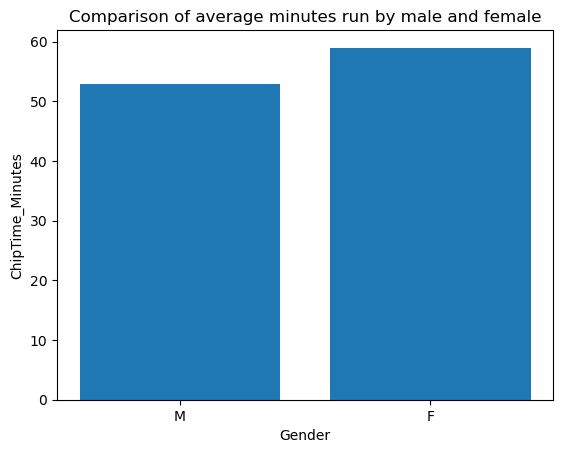

In [86]:
plt.bar(df2['Gender'], df2['ChipTime_minutes'])
plt.xlabel('Gender')
plt.ylabel('ChipTime_Minutes')
plt.title('Comparison of average minutes run by male and female')

In [87]:
df2.describe(include=[np.number])

,ChipTime_minutes,Age_i
count,143,143.000000
mean,0 days 00:00:36,38.195804
std,0 days 00:00:10,12.970855
min,0 days 00:00:16,9.000000
25%,0 days 00:00:28,29.000000
50%,0 days 00:00:34,38.000000
75%,0 days 00:00:44,46.500000
max,0 days 00:00:59,73.000000


Text(0, 0.5, 'Run time')

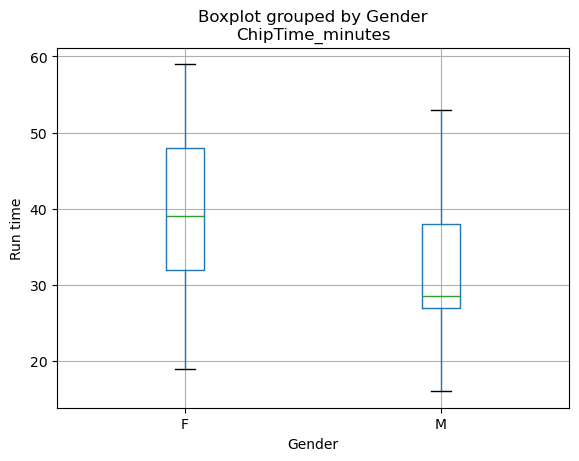

In [91]:
df2['ChipTime_minutes'] = pd.to_numeric(df2['ChipTime_minutes'], errors='coerce')
df2.boxplot(column='ChipTime_minutes', by='Gender')
plt.ylabel('Run time')

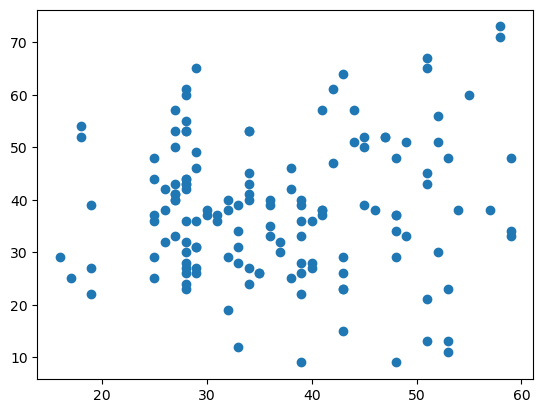

In [92]:
df2['Age_i'] = pd.to_numeric(df2['Age'], errors='coerce').round()
df2.dropna(how='any', inplace=True)
plt.scatter(df2['ChipTime_minutes'], df2['Age_i'])
plt.show()